<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week11/Day6/ExercisesXP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [8]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print ("importations done!")

importations done!


## Exercise 1 - Exploratory Data Analysis

In [3]:
# extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'
EXTRACT_DIR = 'heart_ds'

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:         #  zipfile → opens and extracts the dataset
    zip_ref.extractall(EXTRACT_DIR)

print("Extraction complete")

#list CSV files under EXTRACT_DIR
csv_files = []

for root, dirs, files in os.walk(EXTRACT_DIR):        # os.walk → searches for all .csv files within the folder
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

print("CSV found:", csv_files)

csv_path = csv_files[0]   # set to the CSV you choose

# load the CSV into a DataFrame named df
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# inspect df

print ('\nfirst 5 rows')
print(df.head())

print ('\nShape database')  #small dataset of 270 pacients x 14 columns
print(df.shape)

print ('\nInfo')
print(df.info())  #no missing values

print()
print(f'Duplicates: {df.duplicated().any()}')  #no duplicates

print ('\ndescribe')
print(df.describe()) #we have columns numerical, dicotomic, categoric, discrete numeric

#  0   age                                   adult population
#  1   sex                                   0 = female, 1 = male
#  2   chest pain type
#  3   resting blood pressure
#  4   serum cholestoral
#  5   fasting blood sugar
#  6   resting electrocardiographic results
#  7   max heart rate
#  8   exercise induced angina
#  9   oldpeak                               depresión ST   --> Technical variable
#  10  ST segment                            ST segment slope sign
#  11  major vessels                         color of the heart chambers
#  12  thal                                  thalium stress test result
#  13  heart disease                         target

Extraction complete
CSV found: ['heart_ds/dataset_heart.csv']

first 5 rows
   age  sex  chest pain type  resting blood pressure  serum cholestoral  \
0   70    1                4                     130                322   
1   67    0                3                     115                564   
2   57    1                2                     124                261   
3   64    1                4                     128                263   
4   74    0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             

In [4]:
# identify target column
target = 'heart disease'  # target = what I want to predict

# split features and target
X = df.drop(columns=[target ])  #13 columns
y = df[target].map({1: 0, 2: 1})    #  mapping  applied to y, not to the original DataFrame —  it doesn't pollute the data.

print()
print(y.value_counts())

# train vs test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,       # independent variables
    y,       # target variable
    test_size=0.2,
    random_state=RANDOM_STATE, #42
    stratify=y  #same proportion, maintaining the class ratio
)

print()
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print()
display(y_train.mean()) # ~0.44
display(y_test.mean())  # ~0.44


heart disease
0    150
1    120
Name: count, dtype: int64

Train shape: (216, 13)
Test shape: (54, 13)



np.float64(0.4444444444444444)

np.float64(0.4444444444444444)

In [5]:
class_names = {1:'NOT', 2:'YES'}

counts = df[target].value_counts().rename(index=class_names)
percent = df[target].value_counts(normalize=True).rename(index=class_names) * 100

df_summary = pd.DataFrame({
    'count': counts,
    'percentage': percent.round(1)
})

print ('How many pacients with Heart Disease has the dataset?')
print(df_summary)

How many pacients with Heart Disease has the dataset?
               count  percentage
heart disease                   
NOT              150        55.6
YES              120        44.4


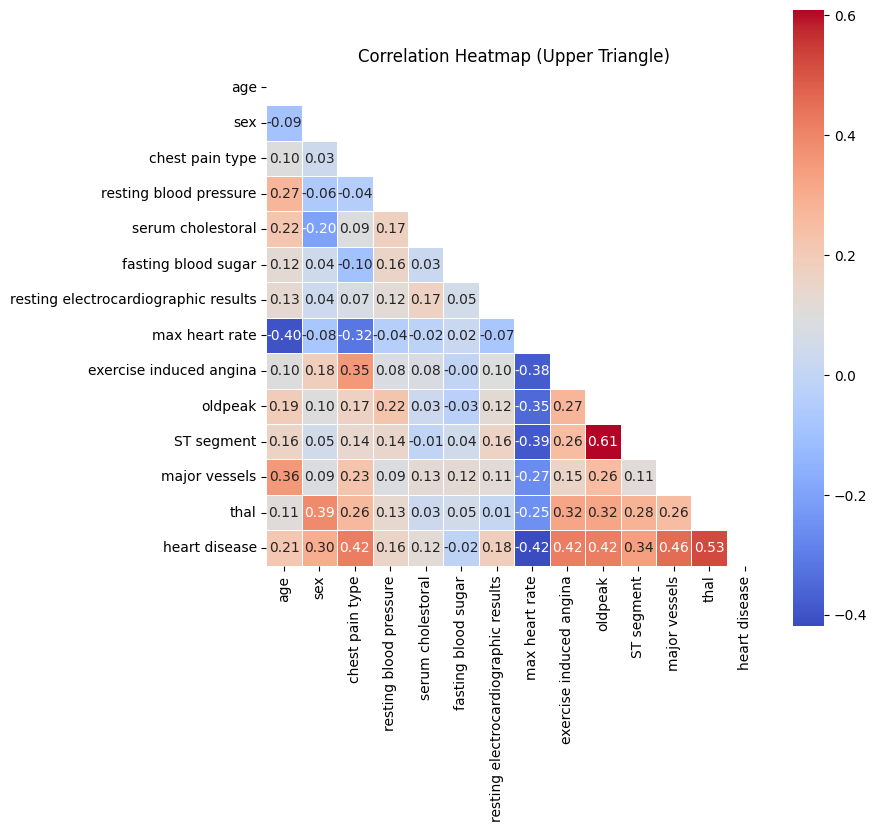

In [9]:
corr = df.corr()  # full base

mask = np.triu(np.ones_like(corr, dtype=bool))  # mask for the upper half

# Heatmap
plt.figure(figsize=(8,8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap (Upper Triangle)")
plt.show()

#The most predictive variables for heart disease appear to be:
# thal 0.53
# major vessels 0.46
# oldpeak  0.42
# exercise induced angina 0.42
# chest pain type 0.42
# max heart rate -0.42

# Basic visual checks

In [11]:
# numeric columns   (5)
num_cols = [
    'age',
    'resting blood pressure',
    'serum cholestoral',
    'max heart rate',
    'oldpeak'
]

# category - bool columns     (8)
cat_cols = [
    'sex',                         # 0 = mujer, 1 = hombre
    'chest pain type',              # 1–4 → tipo de dolor
    'fasting blood sugar',          # 0/1
    'resting electrocardiographic results',  # 0–2
    'exercise induced angina',      # 0/1
    'ST segment',                   # 1–3
    'major vessels',
    'thal'                          # 3, 6, 7
]

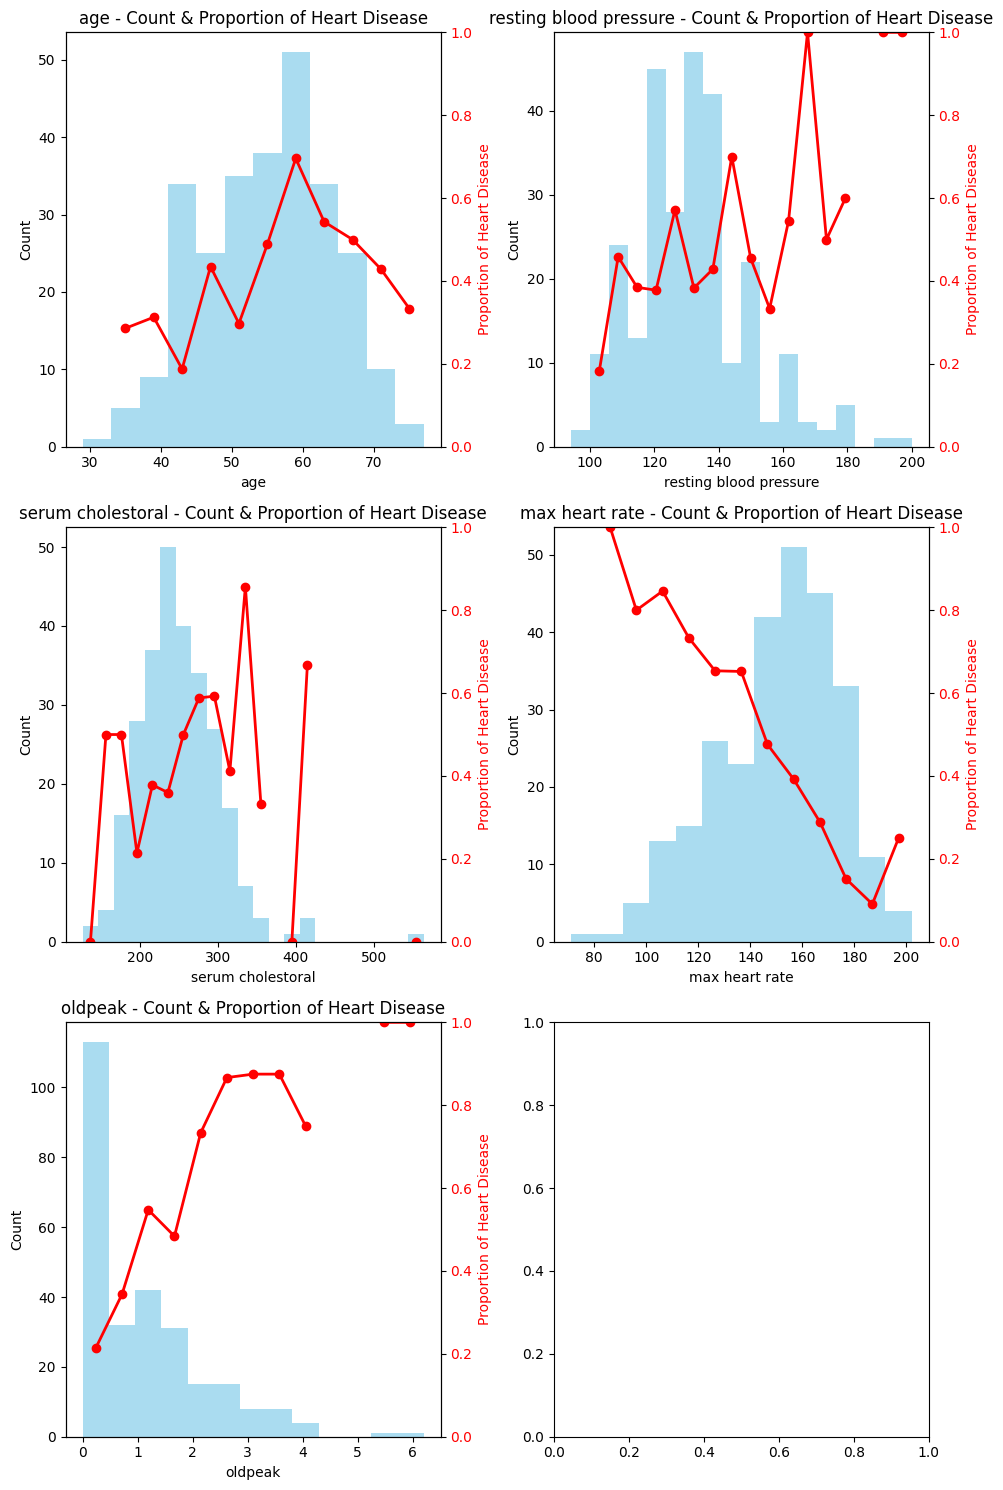

In [12]:
# for numeric columns plot histograms

n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
   bins = np.histogram_bin_edges(df[col], bins='auto')

   counts, edges = np.histogram(df[col], bins=bins)
   centers = (edges[:-1] + edges[1:]) / 2

   axes[i].bar(centers, counts, width=np.diff(edges), color='skyblue', alpha=0.7, label='Count')

   df['bin'] = pd.cut(df[col], bins=bins)
   prop = df.groupby('bin', observed=False)['heart disease'].apply(lambda x: (x==2).mean())

   ax2 = axes[i].twinx()
   ax2.plot(centers, prop.values, color='red', marker='o', linestyle='-', linewidth=2, label='Proportion HD')
   ax2.set_ylim(0, 1)
   ax2.set_ylabel('Proportion of Heart Disease', color='red')
   ax2.tick_params(axis='y', labelcolor='red')

   axes[i].set_title(f'{col} - Count & Proportion of Heart Disease', fontsize=12)
   axes[i].set_xlabel(col)
   axes[i].set_ylabel('Count')

df.drop(columns='bin', inplace=True)

plt.tight_layout()
plt.show()

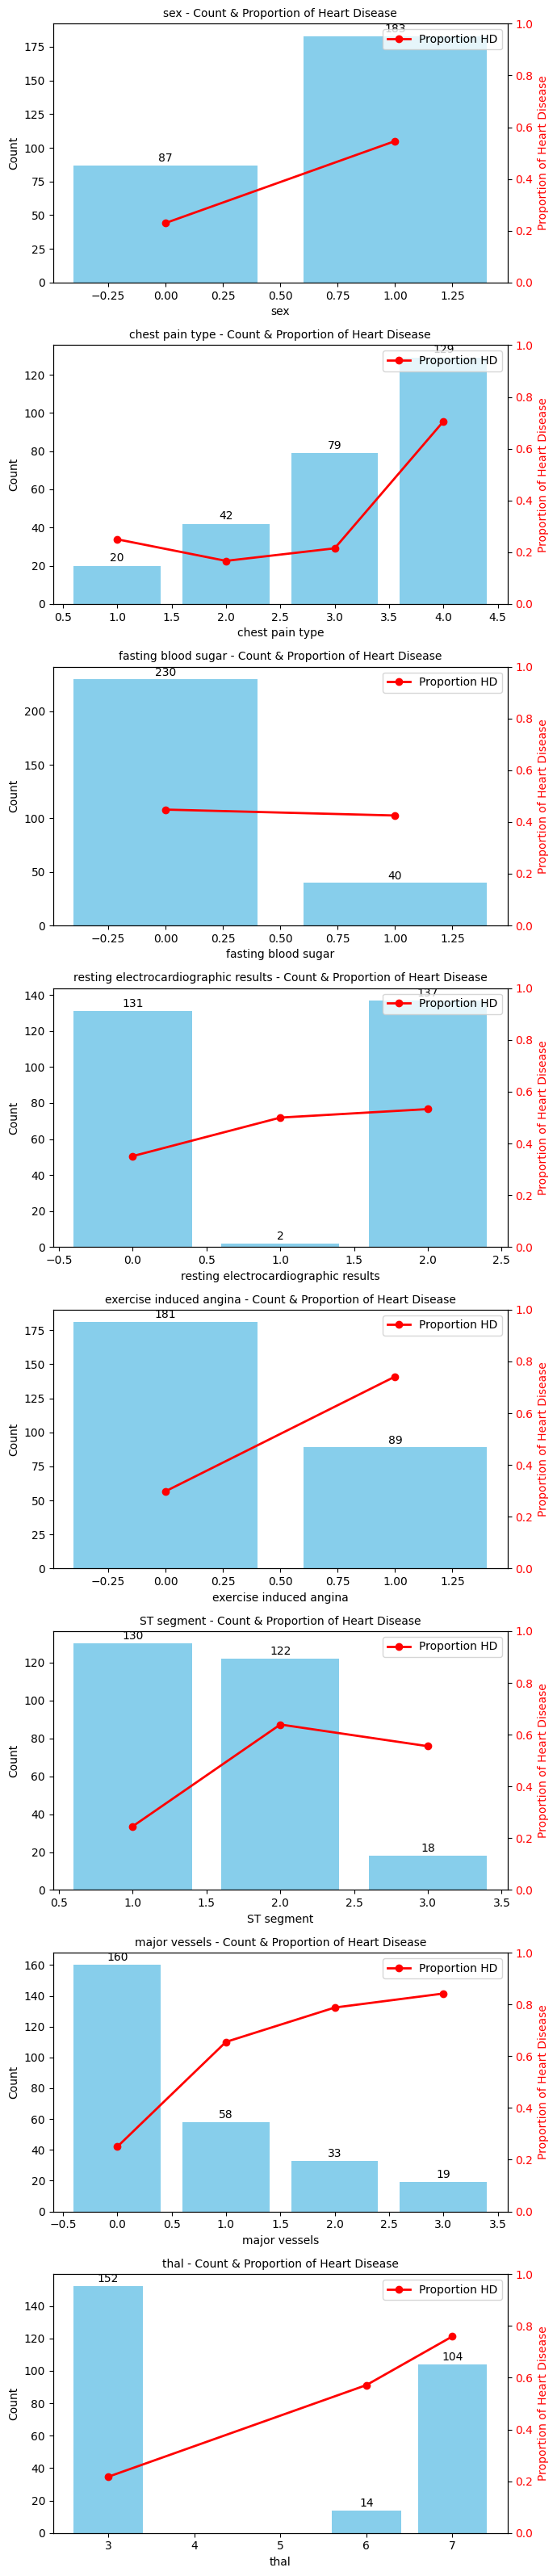

In [13]:
# for category - bool columns plot histograms

fig, axes = plt.subplots(len(cat_cols), 1, figsize=(7, 4 * len(cat_cols)))

for ax, col in zip(axes, cat_cols):

    counts = df[col].value_counts().sort_index()

    prop = df.groupby(col)['heart disease'].apply(lambda x: (x==2).mean()).sort_index()

    bars = ax.bar(counts.index, counts.values, color='skyblue', label='Count')

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1, int(height),
                ha='center', va='bottom', fontsize=10)

    ax2 = ax.twinx()
    ax2.plot(prop.index, prop.values, color='red', marker='o', linestyle='-', linewidth=2, label='Proportion HD')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Proportion of Heart Disease', color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    ax.set_title(f'{col} - Count & Proportion of Heart Disease', fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

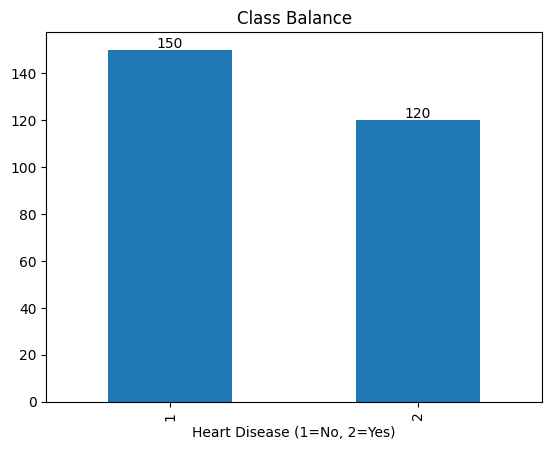

In [14]:
# plot class balance as a bar chart

class_counts = df['heart disease'].value_counts()

ax = class_counts.plot(kind='bar')

plt.title("Class Balance")
plt.xlabel("Heart Disease (1=No, 2=Yes)")

for i, v in enumerate(class_counts):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.show()

# Preprocessing pipeline

In [15]:
# build a ColumnTransformer named pre
pre = ColumnTransformer(
    transformers=[  ('num', StandardScaler(), num_cols),         # StandardScaler for numerical variables
                    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)  ]   # OneHotEncoder for categorical variales
  )

# Helper - evaluation function

In [16]:
# reusable function

def eval_and_report(name, model, X_test, y_test):
    """Compute metrics + draw confusion matrix and ROC if available."""

    # predictions
    y_pred = model.predict(X_test)

    # metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    # report
    print(f"\n{name} Metrics:")
    for k, v in metrics.items():
        print(f"{k}: {v:.3f}")

    # confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Heart Disease', 'Heart Disease'])
    fig, ax = plt.subplots(figsize=(4,4))
    disp.plot(cmap='Blues', ax=ax, colorbar=False)
    plt.title(f'{name} Confusion Matrix')
    plt.show()

    # ROC curve if model has predict_proba
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]  # probability of class 1
        fpr, tpr, thresholds = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(5,5))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
        plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{name} ROC Curve')
        plt.legend(loc='lower right')
        plt.show()

    return metrics

# Exercise 2 - Logistic Regression without Grid Search

In [17]:
# Pipeline
pipe_lr = Pipeline([
    ('pre', pre),      # preprocessing (scaling + encoding)
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))   #model
])

pipe_lr.fit(X_train, y_train)  #Training part

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age',
                                                   'resting blood pressure',
                                                   'serum cholestoral',
                                                   'max heart rate',
                                                   'oldpeak']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'chest pain type',
                                                   'fasting blood sugar',
                                                   'resting '
                                                   'electrocardiographic '
                                                   'results',
                                                   'exercise induced angina',
                                                   'ST segment',
                                                   'major vessels',
                                                   'thal'])])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])


Logistic Regression (no GridSearch) Metrics:
accuracy: 0.870
precision: 0.815
recall: 0.917
f1: 0.863


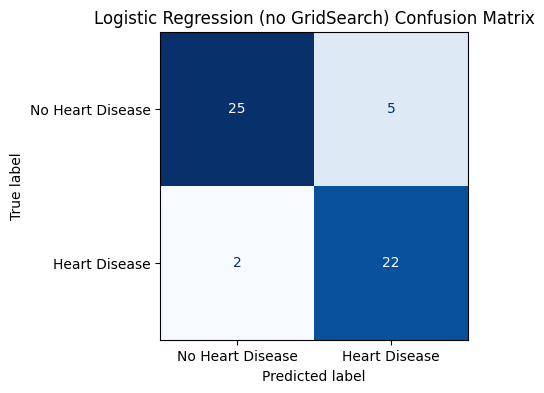

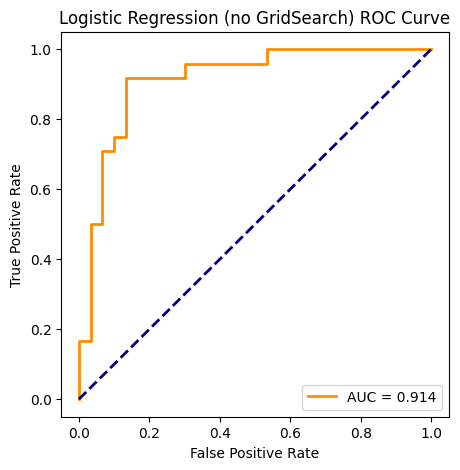

In [18]:
lr_no_gs_metrics = eval_and_report("Logistic Regression (no GridSearch)", pipe_lr, X_test, y_test)  # evaluate with eval_and_report

# Exercise 3 - Logistic Regression with Grid Search

Best params: {'lr__C': 0.1, 'lr__penalty': 'l2'}

Logistic Regression (GridSearch) Metrics:
accuracy: 0.870
precision: 0.815
recall: 0.917
f1: 0.863


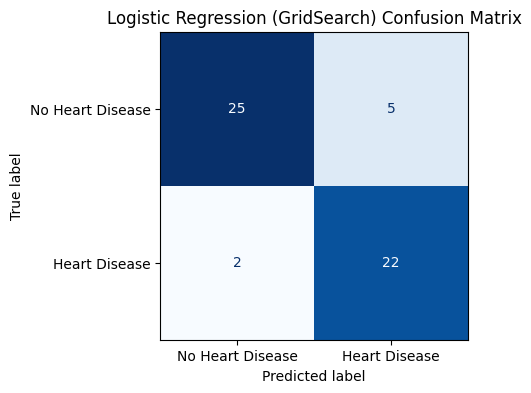

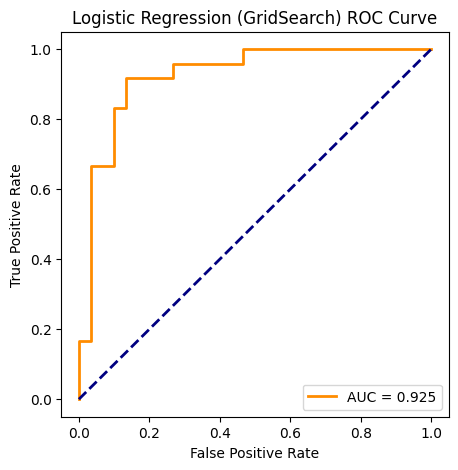

In [19]:
# Pipeline
pipe_lr_cv = Pipeline([
    ('pre', pre),          # preprocessing (scaling + encoding)
    ('lr', LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE))
])

# define param_grid for lr__C and lr__penalty
param_grid = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2']  # 'liblinear' supports 'l1' and 'l2'.
}

# GridSearchCV with cv=5 and scoring='f1'
grid_lr = GridSearchCV(pipe_lr_cv , param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_lr.fit(X_train, y_train)   #Training part

print("Best params:", grid_lr.best_params_)
best_lr = grid_lr.best_estimator_        #use for estimate y_prob
lr_gs_metrics = eval_and_report("Logistic Regression (GridSearch)", best_lr, X_test, y_test)   # Evaluate

# Exercise 4 - SVM without Grid Search


SVM (no GridSearch) Metrics:
accuracy: 0.852
precision: 0.786
recall: 0.917
f1: 0.846


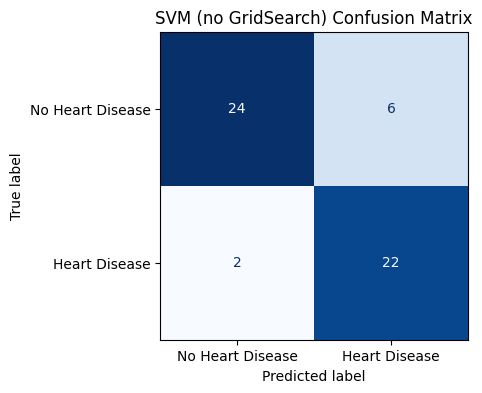

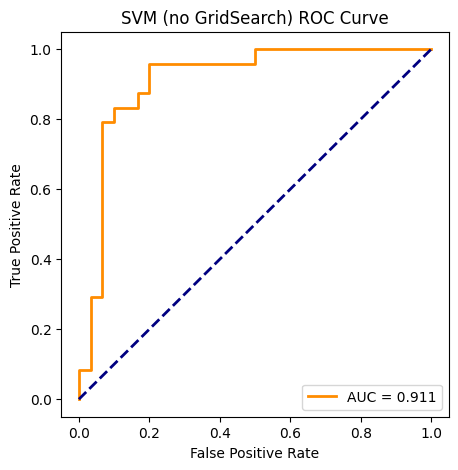

In [20]:
pipe_svm = Pipeline([
    ('pre', pre),     # preprocessing (scaling + encoding)
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE))
])

pipe_svm.fit(X_train, y_train)  #Training part

svm_no_metrics = eval_and_report('SVM (no GridSearch)', pipe_svm, X_test, y_test)   # Evaluate

# Exercise 5 - SVM with Grid Search

Best params: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}

SVM grid Metrics:
accuracy: 0.870
precision: 0.815
recall: 0.917
f1: 0.863


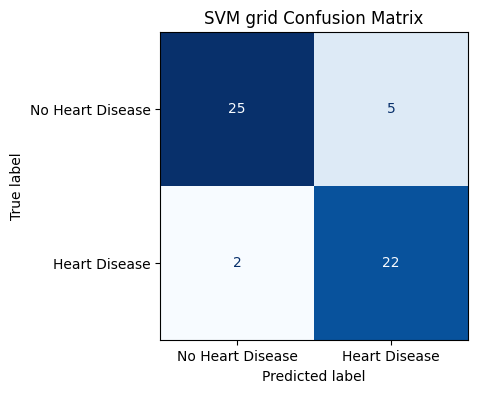

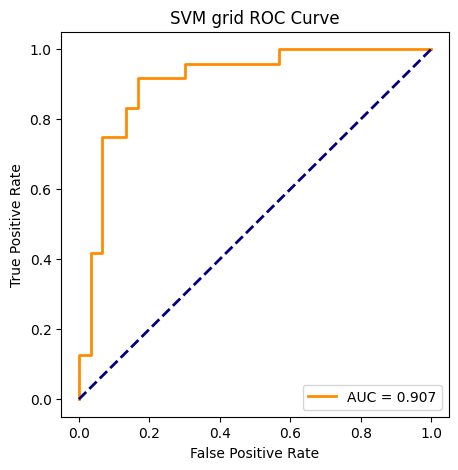

In [21]:
pipe_svm_cv = Pipeline([
    ('pre', pre),     # preprocessing (scaling + encoding)
    ('svm', SVC(probability=True, random_state=RANDOM_STATE))    #probability=True allow to plot ROC
])

# grid
svm_param_grid = {
    'svm__kernel': ['rbf', 'linear'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 'auto', 0.01, 0.1]
}

# GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(
    pipe_svm_cv,
    svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_svm.fit(X_train, y_train)   #Training part

print("Best params:", grid_svm.best_params_)
best_svm = grid_svm.best_estimator_
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test)  # Evaluate

# Exercise 6 - XGBoost without Grid Search


XGBoost (no GridSearch) Metrics:
accuracy: 0.833
precision: 0.800
recall: 0.833
f1: 0.816


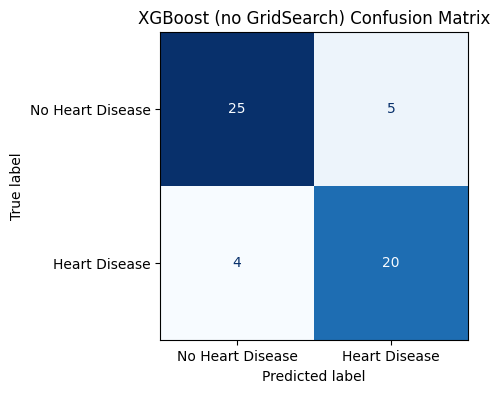

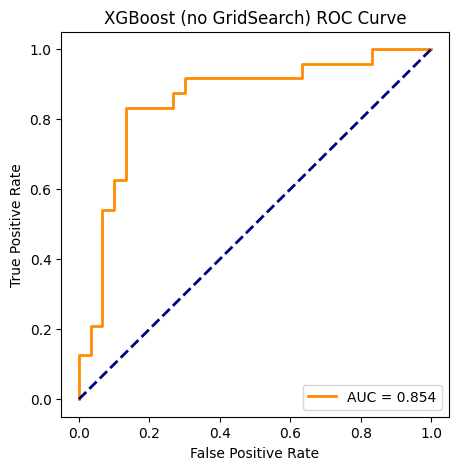

In [22]:
# Pipeline
pipe_xgb = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(
        n_estimators=300,     # n_estimators around 300
        learning_rate=0.1,    # learning_rate 0.1
        max_depth=4,    # max_depth 3 to 5
        random_state=RANDOM_STATE,
       eval_metric='logloss'
    ))
])

pipe_xgb.fit(X_train, y_train)   #Training part

xgb_no_metrics = eval_and_report('XGBoost (no GridSearch)', pipe_xgb, X_test, y_test)  # Evaluate

# Exercise 7 - XGBoost with Grid Search

Best params: {'xgb__colsample_bytree': 1.0, 'xgb__learning_rate': 0.2, 'xgb__max_depth': 4, 'xgb__n_estimators': 300, 'xgb__subsample': 0.8}

XGBoost (GridSearch) Metrics:
accuracy: 0.815
precision: 0.769
recall: 0.833
f1: 0.800


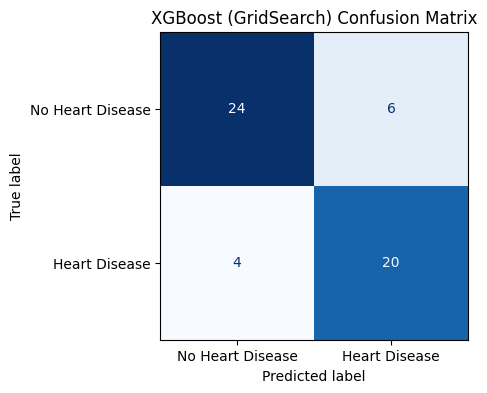

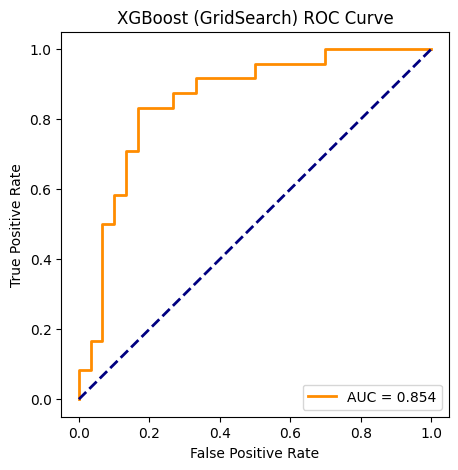

In [23]:
#  Pipeline
pipe_xgb_cv = Pipeline([
    ('pre', pre),
    ('xgb', XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss'
    ))
])

# reasonable param_grid
xgb_param_grid = {
    'xgb__n_estimators': [100, 300, 500],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(
    pipe_xgb_cv,
    xgb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)   #Training part

best_xgb = grid_xgb.best_estimator_
print("Best params:", grid_xgb.best_params_)

xgb_gs_metrics = eval_and_report('XGBoost (GridSearch)', best_xgb, X_test, y_test)  # Evaluate

# Compare models

In [24]:
# comparison DataFrame from the metrics dicts

summary = {}

summary['LR no grid'] = lr_no_gs_metrics
summary['LR grid'] = lr_gs_metrics
summary['SVM no grid'] = svm_no_metrics
summary['SVM grid'] = svm_gs_metrics
summary['XGB no grid'] = xgb_no_metrics
summary['XGB grid'] = xgb_gs_metrics

results_df = pd.DataFrame.from_dict(summary, orient='index')
results_df = results_df.sort_values(by='f1', ascending=False)

print(results_df)

             accuracy  precision    recall        f1
LR no grid   0.870370   0.814815  0.916667  0.862745
LR grid      0.870370   0.814815  0.916667  0.862745
SVM grid     0.870370   0.814815  0.916667  0.862745
SVM no grid  0.851852   0.785714  0.916667  0.846154
XGB no grid  0.833333   0.800000  0.833333  0.816327
XGB grid     0.814815   0.769231  0.833333  0.800000


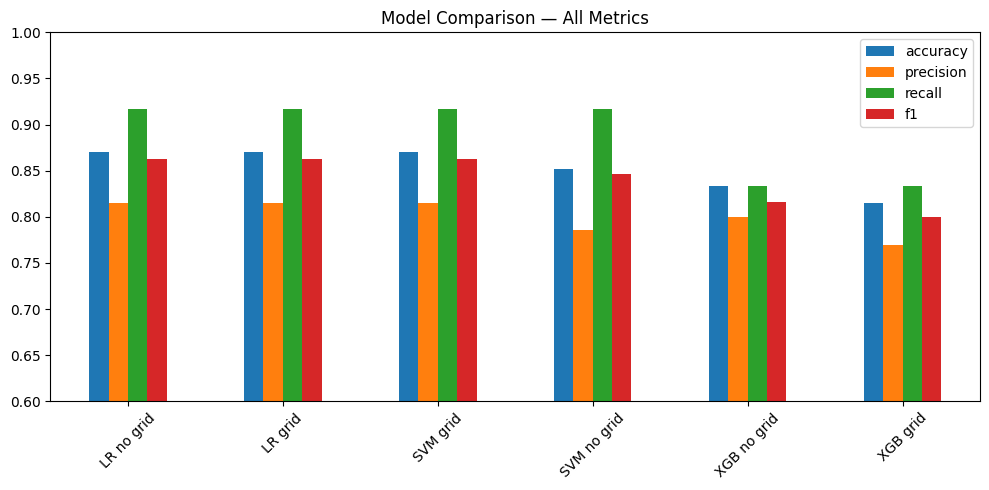

In [25]:
results_df.plot(kind='bar', figsize=(10, 5))
plt.title('Model Comparison — All Metrics')
plt.xticks(rotation=45)
plt.ylim(0.6, 1.0)
plt.legend(loc='lower right')
plt.legend()
plt.tight_layout()
plt.show()

# Insight
6 models were tested: Logistic Regression, SVM, and XGBoost (with and wihout GridSearchCV).

LR no grid, SVM grid, and LR grid yield exactly the same KPIS.

Consecuently, we'd choose LR grid because:

* It's the most interpretable; you can explain each coefficient, which is critical in medicine.
* It's the simplest — less risk of overfitting, easier to maintain in production.
* It was cross-validated — more reliable than the no grid result.
* Recall of 0.917 — detects 91.7% of patients, which is clinically the most important factor.

Why discard the others?

* SVM no grid — same recall but lower accuracy and precision. Worse trade-off.
* XGBoost — clearly inferior in this dataset, probably due to the size of the dataset; with only 270 patients, simple models tend to outperform complex ones.

# Extra: Threshold tuning

In [26]:
# 1° Obtain probabilities of class 1 (Heart Disease = YES)
y_prob = best_lr.predict_proba(X_test)[:, 1]

# Test different thresholds, we are looking for the one which optimizes F1

thresholds = np.linspace(0, 1, 101)
f1_scores = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold: {best_threshold:.2f} with F1-score: {f1_scores[best_idx]:.6f}")

# Optimal threshold: 0.48 with F1-score: 0.862745

Optimal threshold: 0.48 with F1-score: 0.862745


Optimal threshold balancing recall with precision>=0.80: 0.48
Recall with threshold 0.48: 0.917


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

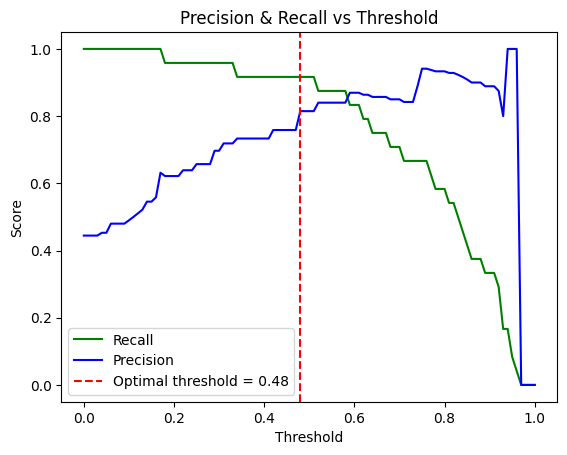

In [27]:
#  Test different thresholds, looking for the one that optimizes Recall with a minimum precision of 0.80
# In medical context, we want to detect the maximum number of patients without sacrificing too much accuracy.

thresholds = np.linspace(0, 1, 101)
recalls = []
precisions = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    recalls.append(recall_score(y_test, y_pred_t))
    precisions.append(precision_score(y_test, y_pred_t))

# Thresholds where precision ≥ 0.80
valid_idx = [i for i, p in enumerate(precisions) if p >= 0.80]

if valid_idx:
    best_idx = valid_idx[np.argmax([recalls[i] for i in valid_idx])]
    best_threshold = thresholds[best_idx]
    print(f"Optimal threshold balancing recall with precision>=0.80: {best_threshold:.2f}")  # => 0.48
else:
    print("No threshold satisfies the minimum precision constraint")

# Threshold = 0.48 = recall 0.917, precision = 0.80  = > similar to Threshold = 0.50

threshold = 0.48
y_pred_048= (y_prob >= threshold).astype(int)
recall_048 = recall_score(y_test, y_pred_048)
print(f"Recall with threshold 0.48: {recall_048:.3f}")

#graph
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.plot(thresholds, precisions, label='Precision', color='blue')
if valid_idx:
    plt.axvline(best_threshold, color='red', linestyle='--', label=f'Optimal threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.show()

# Coefficients
Only available for Logistic Regression, shown here as a reference for feature importance.

In [28]:
# LOGISTIC REGRESSION — COEFFICIENTS

# Extract feature names after the pipeline
ohe_features = best_lr.named_steps['pre'] \
                        .named_transformers_['cat'] \
                        .get_feature_names_out(cat_cols).tolist()

feature_names = num_cols + ohe_features

# Coefficients DataFrame
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': best_lr.named_steps['lr'].coef_[0]
}).sort_values('coefficient', ascending=True)

print(coef_df.to_string(index=False))

print("📌 Coefficient Interpretation:\n")
for _, row in coef_df.iterrows():
    direction = "↑ increases" if row['coefficient'] > 0 else "↓ reduces"
    print(f"  {row['feature']:45s} {direction} heart disease risk  ({row['coefficient']:+.4f})")


                               feature  coefficient
                       major vessels_0    -0.676228
                                thal_3    -0.474857
                                 sex_0    -0.419963
                        max heart rate    -0.310558
             exercise induced angina_0    -0.288086
                          ST segment_1    -0.270902
                     chest pain type_3    -0.243625
                     chest pain type_1    -0.218790
                     chest pain type_2    -0.179035
resting electrocardiographic results_0    -0.111796
                 fasting blood sugar_1    -0.098217
                          ST segment_3    -0.090460
                                thal_6     0.005255
resting electrocardiographic results_1     0.017799
resting electrocardiographic results_2     0.058697
                 fasting blood sugar_0     0.062917
                                   age     0.077695
                     serum cholestoral     0.145853
            

**Top risk factors:**

* chest pain type_4 (+0.60) — asymptomatic chest pain is the most dangerous type. Patients who feel no pain are at highest risk.
* thal_7 (+0.43) — reversible defect in the thalium stress test is a strong cardiac warning sign.
* sex_1 (+0.38) — being male significantly increases risk.

**Top protective factors:**

* major_vessels_0 (-0.68) — the strongest predictor overall. No blocked vessels strongly reduces risk.
* thal_3 (-0.48) — normal thalium test result is strongly protective.
* sex_0 (-0.42) — being female is protective.
* max_heart_rate (-0.31) — higher max heart rate during exercise indicates a healthier heart.

Age has surprisingly almost zero effect (+0.08).